# Batch Size Effect (D3)

Compare training curves with batch sizes: 1, 8, 32, full-batch.

In [2]:
import sys
sys.path.insert(0, '..')
import numpy as np
import matplotlib.pyplot as plt
from network import Network, NetworkConfig
from optimizer import Adam

bs=   1: final loss = 0.000010
bs=   8: final loss = 0.002022
bs=  32: final loss = 0.068045
bs= 100: final loss = 0.144450


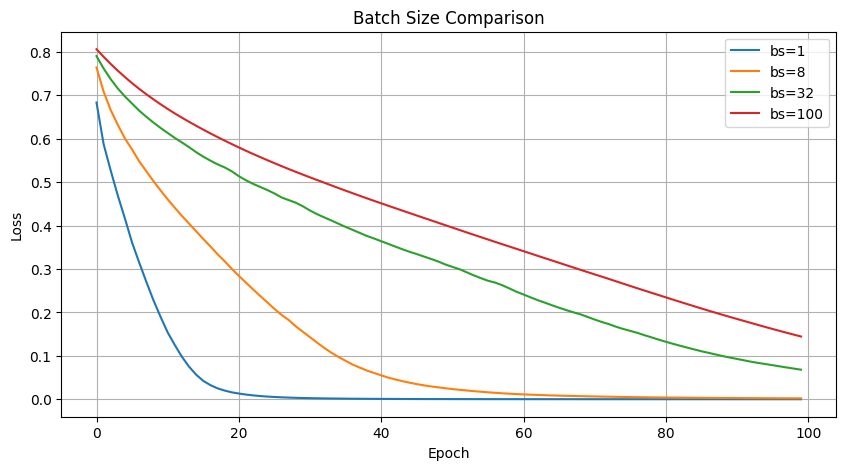

In [3]:
np.random.seed(42)
x = np.random.randn(100, 30)
y = np.zeros((100, 2))
y[np.arange(100), np.random.randint(0, 2, 100)] = 1

batch_sizes = [1, 8, 32, 100]
plt.figure(figsize=(10, 5))

for bs in batch_sizes:
    np.random.seed(42)
    net = Network(NetworkConfig(layers=[30, 24, 24, 24, 2], activation='relu',
        loss='cross_entropy', output_activation='softmax', weights_initializer='heUniform'))
    opt = Adam(learning_rate=0.001)
    losses = []
    for epoch in range(100):
        idx = np.arange(len(x)); np.random.shuffle(idx)
        xs, ys = x[idx], y[idx]
        for i in range(0, len(x), bs):
            net.forward(xs[i:i+bs])
            nw, nb = net.backward(ys[i:i+bs])
            opt.update(net, nw, nb)
        losses.append(net.loss(y, net.forward(x)))
    print(f'bs={bs:>4}: final loss = {losses[-1]:.6f}')
    plt.plot(losses, label=f'bs={bs}')

plt.title('Batch Size Comparison')
plt.xlabel('Epoch'); plt.ylabel('Loss')
plt.legend(); plt.grid(True); plt.show()